In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))
parquet_files

[PosixPath('data/futures/6E.parquet'),
 PosixPath('data/futures/6J.parquet'),
 PosixPath('data/futures/CL.parquet'),
 PosixPath('data/futures/ES.parquet'),
 PosixPath('data/futures/GC.parquet'),
 PosixPath('data/futures/NG.parquet'),
 PosixPath('data/futures/NQ.parquet'),
 PosixPath('data/futures/SI.parquet'),
 PosixPath('data/futures/YM.parquet'),
 PosixPath('data/futures/ZB.parquet'),
 PosixPath('data/futures/ZN.parquet')]

In [2]:
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)

    # flatten multi index
    df.columns = [c[0] for c in df.columns]

    df["ticker"] = f.stem
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True, sort=False)
# df = df[df["ticker"] == "6E"]

In [3]:
def get_earliest_per_ticker(df):
    return df.groupby("ticker")["timestamp"].min().reset_index().sort_values("timestamp")
get_earliest_per_ticker(df)

,ticker,timestamp
2,CL,2000-08-23
4,GC,2000-08-30
5,NG,2000-08-30
7,SI,2000-08-30
0,6E,2000-09-12
1,6J,2000-09-13
3,ES,2000-09-18
6,NQ,2000-09-18
9,ZB,2000-09-21
10,ZN,2000-09-21


In [4]:
# remove rows with timestamps before 2002-04-05
import datetime
cutoff = datetime.datetime(2002, 4, 5)
df = df[df["timestamp"] >= cutoff].reset_index(drop=True)
df

,timestamp,close,high,low,open,volume,ticker
0,2002-04-05,0.876700,0.878900,0.874800,0.875500,0,6E
1,2002-04-08,0.871600,0.876900,0.871100,0.876700,0,6E
2,2002-04-09,0.878100,0.878500,0.871200,0.872100,0,6E
3,2002-04-10,0.878000,0.880000,0.876400,0.878500,0,6E
4,2002-04-11,0.880700,0.882300,0.876800,0.878000,0,6E
...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [5]:
import numpy as np
import pandas as pd

def get_causal_tokens(df, n_bins=10):
    # 1. Calculate ATR (Trailing only)
    # Using 'high' and 'low' directly for TR to avoid look-ahead
    prev_close = df["close"].shift(1)
    high_low = df["high"] - df["low"]
    high_pc = (df["high"] - prev_close).abs()
    low_pc = (df["low"] - prev_close).abs()
    
    tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()

    # 2. Features
    
    # A. Candle Shape (Differential)
    # How much did we move today relative to vol?
    conviction = (df["close"] - df["open"]) / atr
    explosion = (df["high"] - df["low"]) / atr
    
    # B. Trend Context (Integral) - CRITICAL UPDATE
    # Where are we relative to the 20-day mean? (Proxy for visual trend)
    ma_20 = df["close"].rolling(20).mean()
    trend_score = (df["close"] - ma_20) / atr
    
    # C. Relative Volume
    # Add small epsilon to avoid div by zero
    vol_ma = df["volume"].rolling(50).mean() + 1e-12
    rel_volume = (df["volume"] + 1e-12) / vol_ma

    # 3. Discretization (Fixed Bins to avoid Look-Ahead)
    # We assume standardized features roughly follow N(0,1) or similar.
    # We explicitly define bins rather than learning them from the future.
    
    def digitize_feature(series, min_val, max_val, bins):
        # Clip outliers
        clipped = series.clip(min_val, max_val)
        # Linearly space bins (or you can use norm.ppf for gaussian spacing)
        # This creates integer codes 0 to bins-1
        return pd.cut(clipped, bins=bins, labels=False, include_lowest=True)

    # Conviction: usually within -3 to 3 ATR
    c_codes = digitize_feature(conviction, -3, 3, n_bins)
    
    # Trend: usually within -5 to 5 ATR
    t_codes = digitize_feature(trend_score, -5, 5, n_bins)
    
    # Volume: usually 0 to 5x average
    v_codes = digitize_feature(rel_volume, 0, 5, n_bins)

    # Explosion
    e_codes = digitize_feature(explosion, -3, 3, n_bins)

    # 4. Create Tokens
    # Format: "C{code}_T{code}_V{code}"
    # Using Int64 to handle NaNs gracefully
    df_codes = pd.DataFrame({
        'c': c_codes,
        't': t_codes,
        'v': v_codes,
        "e": e_codes
    }).astype("Int64")

    # Drop early rows where rolling window features are NaN
    df_codes = df_codes.dropna()
    
    tokens = (
        df_codes['c'].astype(str) + "_" + 
        df_codes['t'].astype(str) + "_" + 
        df_codes['v'].astype(str) + "_" + 
        df_codes["e"].astype(str)
    )
    
    # Align indices
    tokens = tokens.reindex(df.index)
    
    return tokens

number_of_classes = 3
feature_bins = 10
# compute tokens per ticker and store back into the main df
df['token'] = None
for _, g in df.groupby('ticker', sort=False):
    df.loc[g.index, 'token']= get_causal_tokens(g, n_bins=feature_bins)

In [6]:
def get_return(df, periods=1):
    # 1. Use Log Returns (Approximates % change, but additive and symmetric)
    # Formula: ln(Price_future / Price_current)
    # We shift 'close' backwards by 'periods' to compare Today vs. Future
    
    future_close = df["close"].shift(-periods)
    
    # Calculate return
    # If future > current, this is positive.
    df["log_ret"] = np.log(future_close / df["close"])
    
    # 2. (Optional but Recommended) Volatility Normalization
    # This matches the "Sharpe Ratio" logic of the paper.
    # We divide the return by the daily volatility (ATR or Std Dev).
    # This helps the model distinguish a "significant move" from noise.
    
    # Calculate 20-day volatility (standard deviation of log returns)
    daily_log_ret = np.log(df["close"] / df["close"].shift(1))
    volatility = daily_log_ret.rolling(20).std()
    
    # The Target: "How many standard deviations will price move?"
    df["target"] = df["log_ret"] / volatility
    
    return df

def get_hurdle_target(df, cost_threshold=0.002): # e.g. 0.2% hurdle
    # ... calc returns ...
    
    # 0 = sell, 1 = neutral, 2 = buy
    df['target'] = 1
    
    # Only buy if return > cost hurdle
    df.loc[df['ret'] > cost_threshold, 'target'] = 1
    
    # Only sell if return < -cost hurdle
    df.loc[df['ret'] < -cost_threshold, 'target'] = 2
    
    return df

def get_target(df, periods=1, sigma_threshold=0.5):
    # --- 1. Calculate Future Return ---
    # Shift backwards to see what happens 'periods' days later
    future_close = df["close"].shift(-periods)
    
    # Log returns (Additive, symmetric)
    df["log_ret"] = np.log(future_close / df["close"])
    
    # --- 2. Normalize by Volatility (The "JKX" Paper Trick) ---
    # Calculate daily volatility (trailing 20 days) to avoid look-ahead
    daily_returns = np.log(df["close"] / df["close"].shift(1))
    volatility = daily_returns.rolling(20).std()
    
    # Calculate "Normalized Return" (Z-Score)
    # Value of 2.0 means price moved 2 standard deviations
    df["norm_ret"] = df["log_ret"] / volatility
    
    # --- 3. Create Classes (The Hurdle) ---
    # We use the Normalized Return for the hurdle
    # 0 = Sell (Significant Down Move)
    # 1 = Neutral (Noise / Small Move)
    # 2 = Buy (Significant Up Move)
    
    # Initialize all as Neutral (1)
    df["target"] = 1
    
    # Buy: If move is > +0.5 sigma
    df.loc[df["norm_ret"] > sigma_threshold, "target"] = 2
    
    # Sell: If move is < -0.5 sigma
    df.loc[df["norm_ret"] < -sigma_threshold, "target"] = 0
    
    # Cleanup: Drop NaN values generated by rolling window and shift
    return df.dropna()

df = get_target(df)
df["target"].value_counts(normalize=True)

/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


target
1    0.411658
2    0.309496
0    0.278846
Name: proportion, dtype: float64

In [7]:
bigger_df = pd.read_parquet("data/ibm_data.parquet").rename(columns={"symbol": "ticker"})
bigger_df["token"] = get_causal_tokens(bigger_df)
bigger_df = get_target(bigger_df)
bigger_df = bigger_df.dropna()
# df = bigger_df

massive_df = pd.read_parquet("data/small_group").rename(columns={"symbol": "ticker"})
massive_df["token"] = get_causal_tokens(massive_df)
massive_df = get_target(massive_df)
massive_df = massive_df.dropna()
df = massive_df

In [8]:
# align all tickers to a common timestamp index and rebuild a compact (T_common, N, 1) integer array
# pivot tokens so each column is a ticker and index are timestamps
token_pivot = df.pivot(index="timestamp", columns="ticker", values="token").sort_index()
ret_pivot = df.pivot(index="timestamp", columns="ticker", values="target").sort_index()


# keep only timestamps present for every ticker
common_mask = token_pivot.notna().all(axis=1) & ret_pivot.notna().all(axis=1)
T_common = int(common_mask.sum())
print("T_common:", T_common)

# restrict pivot to the common timestamps (ensures every column has the same index)
token_pivot = token_pivot.loc[common_mask]
ret_pivot = ret_pivot.loc[common_mask]

# tickers in consistent order
tickers = token_pivot.columns.tolist()
N = len(tickers)
print("N (tickers):", N, "tickers:", tickers)

# split token strings into three component classes (conviction, explosion, rel_volume)
c_pivot = token_pivot.applymap(lambda s: int(s.split("_")[0]))
t_pivot = token_pivot.applymap(lambda s: int(s.split("_")[1]))
v_pivot = token_pivot.applymap(lambda s: int(s.split("_")[2]))
e_pivot = token_pivot.applymap(lambda s: int(s.split("_")[3]))

# as numpy arrays (T_common, N)
c_arr = c_pivot.values.astype(np.int32)
e_arr = e_pivot.values.astype(np.int32)
t_arr = t_pivot.values.astype(np.int32)
v_arr = v_pivot.values.astype(np.int32)


# combined array with last dim = 3 (conviction, explosion, rel_volume)
class_arr = np.stack([c_arr, e_arr, t_arr, v_arr], axis=-1)

# show result (replace with any further processing you need)
c_pivot.head()

T_common: 18064
N (tickers): 49 tickers: ['AAPL', 'ABBV', 'ABT', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'AXP', 'BAC', 'BLK', 'BRK.B', 'CAT', 'COST', 'CRM', 'CSCO', 'CVX', 'DIS', 'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'INTU', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'QCOM', 'TMO', 'TSLA', 'TXN', 'UNH', 'V', 'WFC', 'WMT', 'XOM']


/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_3831/1087201834.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  c_pivot = token_pivot.applymap(lambda s: int(s.split("_")[0]))
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_3831/1087201834.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  t_pivot = token_pivot.applymap(lambda s: int(s.split("_")[1]))
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_3831/1087201834.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  v_pivot = token_pivot.applymap(lambda s: int(s.split("_")[2]))
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_3831/1087201834.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  e_pivot = token_pivot.applymap(lambda s: int(s.split("_")[3]))


ticker,AAPL,ABBV,ABT,ADBE,AMD,AMZN,AVGO,AXP,BAC,BLK,...,PG,QCOM,TMO,TSLA,TXN,UNH,V,WFC,WMT,XOM
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-07 14:00:00+00:00,5,4,4,7,6,3,6,8,6,6,...,7,3,3,6,6,4,5,4,9,8
2016-01-07 15:00:00+00:00,6,6,5,7,3,7,5,4,5,5,...,4,4,6,5,5,5,9,5,5,6
2016-01-07 16:00:00+00:00,3,5,4,3,4,3,4,4,3,2,...,4,4,3,4,3,4,3,4,4,3
2016-01-07 17:00:00+00:00,3,4,4,4,5,3,4,4,3,4,...,4,3,4,5,4,4,4,3,5,5
2016-01-07 18:00:00+00:00,4,4,3,3,4,2,3,5,4,3,...,4,2,4,3,2,3,2,3,4,3


In [9]:
ret_pivot

ticker,AAPL,ABBV,ABT,ADBE,AMD,AMZN,AVGO,AXP,BAC,BLK,...,PG,QCOM,TMO,TSLA,TXN,UNH,V,WFC,WMT,XOM
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-07 14:00:00+00:00,2.0,2.0,1.0,2.0,0.0,2.0,1.0,1.0,1.0,1.0,...,1.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0
2016-01-07 15:00:00+00:00,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2016-01-07 16:00:00+00:00,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
2016-01-07 17:00:00+00:00,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2016-01-07 18:00:00+00:00,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 17:00:00+00:00,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2024-12-31 18:00:00+00:00,2.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,...,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0
2024-12-31 19:00:00+00:00,1.0,2.0,2.0,1.0,1.0,0.0,0.0,1.0,2.0,2.0,...,2.0,1.0,2.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0


In [10]:
df = df.dropna()
vocab = df["token"].unique().tolist()
vocab_len = len(vocab)

T = len(token_pivot)
N = len(df["ticker"].unique())

T, N

(18064, 49)

In [11]:
# build integer mapping once (vocab is defined in the notebook)
# token_to_id = {tok: i for i, tok in enumerate(range(vocab)}

# allocate array (T,N,1) with integer dtype
all_sequences = np.zeros((T, N, 4), dtype=np.int32)
all_targets = np.zeros((T, N))

for idx, sym in enumerate(tickers):
    seq_ids = np.array([
        c_pivot[sym].astype(np.int32).values, 
        t_pivot[sym].astype(np.int32).values, 
        v_pivot[sym].astype(np.int32).values, 
        e_pivot[sym].astype(np.int32).values
        ])

    # print(seq_ids.T.shape)
    # assert seq_ids.shape[0] == T
    all_sequences[:, idx] = seq_ids.T
    all_targets[:, idx] = ret_pivot[sym].astype(np.int32)

all_sequences.shape, all_sequences.dtype

((18064, 49, 4), dtype('int32'))

In [12]:
all_targets

array([[2., 2., 1., ..., 1., 1., 2.],
       [0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 1., ..., 0., 1., 1.],
       ...,
       [1., 2., 2., ..., 1., 1., 0.],
       [1., 1., 2., ..., 1., 1., 1.],
       [1., 2., 0., ..., 1., 1., 0.]], shape=(18064, 49))

In [13]:
# build dataset

# build dataloader

# instantiate model

# train model

# inspect

In [14]:
from model.my_dataset import MyDataset
from torch.utils.data import DataLoader
from model.model_definition import SimpleTransformer
from model.training import train_loop
import torch

In [15]:
np.unique(all_targets)

array([0., 1., 2.])

In [16]:
class_freqs = np.unique(all_targets, return_counts=True)[1]
class_freqs, number_of_classes

(array([203135, 471510, 210491]), 3)

In [17]:
SEQ_LEN = 8
BATCH_SIZE = 128 # the batches chosen should be set up so that the components of each batch are sequential, then shuffle the order of batches/batches, custom dataloader

train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], SEQ_LEN)
tmp = []
[tmp.append(train_dataset[i]) for i in range(30)]
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], SEQ_LEN)
tmp2 = []
[tmp2.append(val_dataset[i]) for i in range(30, 40)]


train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # pin_memory=True and num_workers=4+
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True) # pin_memory=True and num_workers=4+



# pass frequencies to the model (as a list)
model = SimpleTransformer(feature_bins, SEQ_LEN, number_of_classes, symbol_count=N, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)

res = train_loop(model, train_dataloader, val_dataloader, 50, 4e-4, 1e-5, torch.device("cpu"), "checkpoint", 8)

Training on device: cpu
Trainable parameters: 58115
Training samples: 14324, Validation samples: 3486
--------------------------------------------------------------------------------


KeyboardInterrupt: 

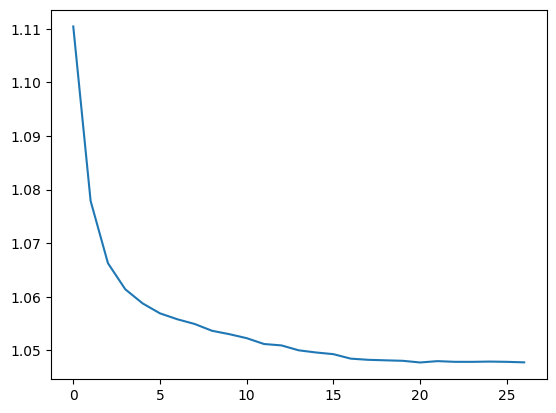

In [ ]:
plt.plot(res["history"]["train_loss"])

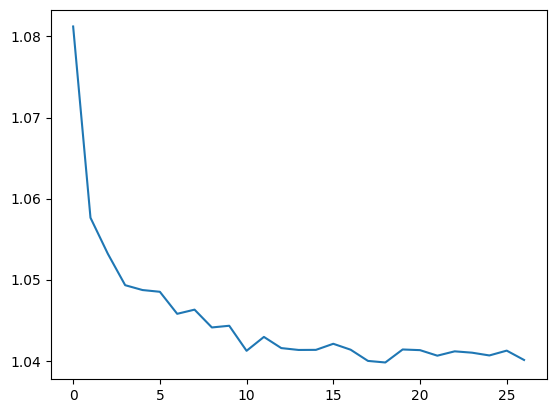

In [ ]:
plt.plot(res["history"]["val_loss"])

In [ ]:
SEQ_LEN=8
BATCH_SIZE=1

m2 = SimpleTransformer(feature_bins, SEQ_LEN, number_of_classes, symbol_count=N, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)
info = torch.load("checkpoint/best_model.pt")
m2.load_state_dict(info["model_state_dict"])

train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], SEQ_LEN)
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], SEQ_LEN)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE) # pin_memory=True and num_workers=4+
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE) # pin_memory=True and num_workers=4+


In [ ]:
model = m2
model.eval()
all_preds = []
with torch.no_grad():
    for x_batch, y_batch in val_dataloader:
        preds, _ = model(x_batch)
        all_preds.append(preds)
        # print(preds)
all_preds

[tensor([[[[0.4055, 0.1920, 0.4025],
           [0.3872, 0.2228, 0.3901],
           [0.3826, 0.2327, 0.3847],
           [0.4089, 0.1853, 0.4058],
           [0.4168, 0.1729, 0.4103],
           [0.4208, 0.1620, 0.4171],
           [0.4104, 0.1810, 0.4086],
           [0.4121, 0.1803, 0.4076],
           [0.4170, 0.1811, 0.4018],
           [0.4160, 0.1714, 0.4126],
           [0.4148, 0.1805, 0.4047],
           [0.4211, 0.1696, 0.4092],
           [0.4140, 0.1780, 0.4080],
           [0.4248, 0.1577, 0.4175],
           [0.4214, 0.1688, 0.4099],
           [0.4263, 0.1619, 0.4118],
           [0.4216, 0.1637, 0.4147],
           [0.4286, 0.1518, 0.4196],
           [0.4176, 0.1692, 0.4132],
           [0.4012, 0.2012, 0.3977],
           [0.4236, 0.1601, 0.4163],
           [0.4275, 0.1536, 0.4189],
           [0.4124, 0.1837, 0.4040],
           [0.4232, 0.1594, 0.4174],
           [0.4203, 0.1671, 0.4125],
           [0.4153, 0.1759, 0.4088],
           [0.4172, 0.1701, 0.4127],
 

In [ ]:
preds = torch.stack(all_preds).squeeze(1).squeeze(1).detach().cpu().numpy()
preds.shape # (timesteps, N, output_classes)

(3606, 49, 3)

In [ ]:
import numpy as np

def build_decile_signals(preds, top_pct=0.10):
    """
    Build top-decile long / short boolean signals from model softprob preds.

    Args:
        preds : np.ndarray, shape (T, N, C) or (N, U, C)
            Softmax probabilities where class 0=negative, 1=neutral, 2=positive.
        top_pct : float
            Fraction for the decile (0.10 -> top 10% longs, top 10% negatives -> shorts).

    Returns:
        long_signal, short_signal : np.ndarray of dtype bool, shape (T, N)
            long_signal[t,i] == True means asset i at timestep t is in the long decile.
            short_signal[t,i] == True means asset i at timestep t is in the short decile.
    """
    arr = np.asarray(preds)
    if arr.ndim != 3:
        raise ValueError("preds must be a 3D array (T, N, C)")

    # ensure shape: (T, N, C)
    T, N, C = arr.shape
    pos = arr[:, :, 2]
    neg = arr[:, :, 0]

    # per-timestep thresholds (percentiles computed over assets)
    p_high = 100 * (1.0 - top_pct)
    pos_thresh = np.nanpercentile(pos, p_high, axis=1)  # shape (T,)
    neg_thresh = np.nanpercentile(neg, p_high, axis=1)  # shape (T,)

    # broadcast thresholds and pick top decile
    long_mask = pos >= pos_thresh[:, None]
    short_mask = neg >= neg_thresh[:, None]

    # resolve any overlaps (both True). use higher margin (pos-neg) to break ties.
    overlap = long_mask & short_mask
    if overlap.any():
        margin = pos - neg
        # where margin > 0 prefer long, else prefer short
        prefer_long = margin > 0
        # for overlapping cells, assign per preference
        long_mask[overlap] = prefer_long[overlap]
        short_mask[overlap] = (~prefer_long)[overlap]

    return long_mask.astype(bool), short_mask.astype(bool)


# Example usage in this notebook:
# assuming `preds` is a numpy array shape (timesteps, n_assets, 3)
# long_signal, short_signal = build_decile_signals(preds, top_pct=0.10)
# These arrays can be passed directly to vectorbt or similar backtest code.
long_signal, short_signal = build_decile_signals(preds)

In [ ]:
preds

array([[[0.40548778, 0.19200066, 0.4025115 ],
        [0.3871703 , 0.22277586, 0.3900538 ],
        [0.38259962, 0.23268892, 0.3847114 ],
        ...,
        [0.42728803, 0.1617889 , 0.4109231 ],
        [0.41717988, 0.17141859, 0.41140154],
        [0.43175787, 0.15616135, 0.4120808 ]],

       [[0.39980254, 0.19842519, 0.40177232],
        [0.40269604, 0.1922695 , 0.40503445],
        [0.37414795, 0.2453769 , 0.3804752 ],
        ...,
        [0.43872106, 0.14485912, 0.41641986],
        [0.4257996 , 0.1641771 , 0.41002336],
        [0.42322853, 0.15533476, 0.42143667]],

       [[0.35787094, 0.27544415, 0.3666849 ],
        [0.32891378, 0.32667324, 0.34441304],
        [0.30769637, 0.37223506, 0.3200686 ],
        ...,
        [0.3722221 , 0.25424927, 0.3735286 ],
        [0.3593775 , 0.27178878, 0.3688337 ],
        [0.36175287, 0.26027122, 0.37797585]],

       ...,

       [[0.37049806, 0.25820577, 0.3712962 ],
        [0.366095  , 0.26349524, 0.37040982],
        [0.3670269 , 0

In [ ]:
long_signal = preds[:, :, 2] > 0.4
short_signal = preds[:, :, 0] > 0.4 
neutral = ~(long_signal | short_signal)  # elementwise NOT of the elementwise OR
neutral.shape

(3606, 49)

In [ ]:
long_signal.sum(), short_signal.sum()

(np.int64(31542), np.int64(31793))

In [ ]:
close_prices = []
for _, g in df.groupby("ticker"):
    close_price = g[-preds.shape[0]:].sort_index()["close"].values
    close_prices.append(close_price)

close_prices = np.stack(close_prices).T
close_prices.shape

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/1063359289.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



(3606, 49)

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/2513715920.py:13: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x10763b100>. Pass column to select a single column/group.

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/2513715920.py:22: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



Start                                                   0
End                                                  3605
Period                                  150 days 06:00:00
Start Value                                         100.0
End Value                                       94.603958
Total Return [%]                                -5.396042
Benchmark Return [%]                            19.318827
Max Gross Exposure [%]                              100.0
Total Fees Paid                                  7.788628
Max Drawdown [%]                                30.697373
Max Drawdown Duration         102 days 02:46:31.836734694
Total Trades                                   214.285714
Total Closed Trades                            213.285714
Total Open Trades                                     1.0
Open Trade PnL                                  -0.749176
Win Rate [%]                                    49.031527
Best Trade [%]                                  12.586299
Worst Trade [%

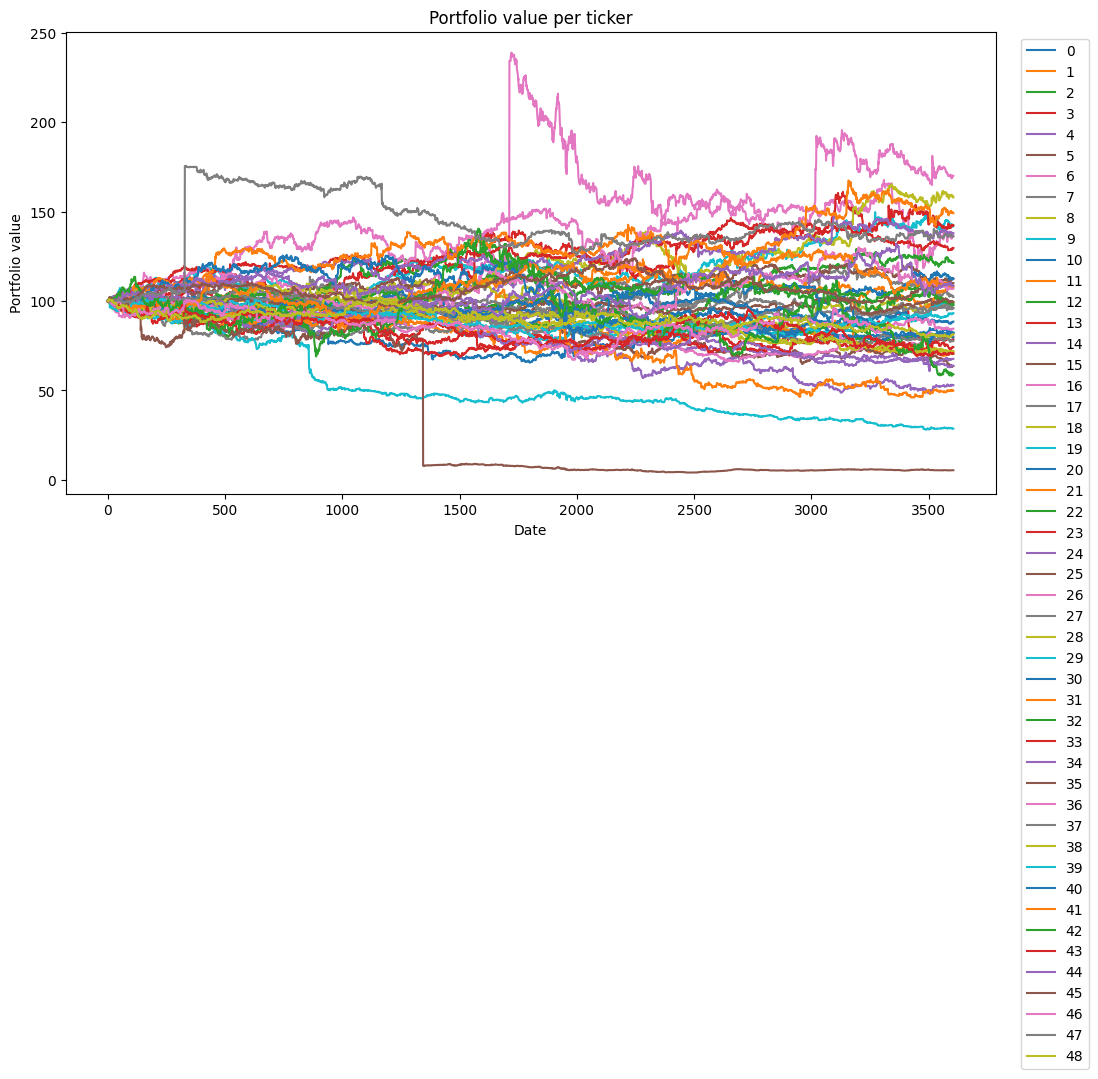

In [ ]:
import vectorbt as vbt

portfolio = vbt.Portfolio.from_signals(
    close = close_prices,
    entries = long_signal,
    exits = short_signal,
    short_entries = short_signal,
    short_exits = long_signal,
    fees = 0.0002,
    freq = "1h"
)

st = portfolio.stats()
print(st)
# plot equity curves using pandas / matplotlib (supports multiple columns)
pf_value = portfolio.value()  # DataFrame with index=dates and columns=tickers
pf_value.plot(figsize=(12, 6))
plt.title("Portfolio value per ticker")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend(loc="best", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

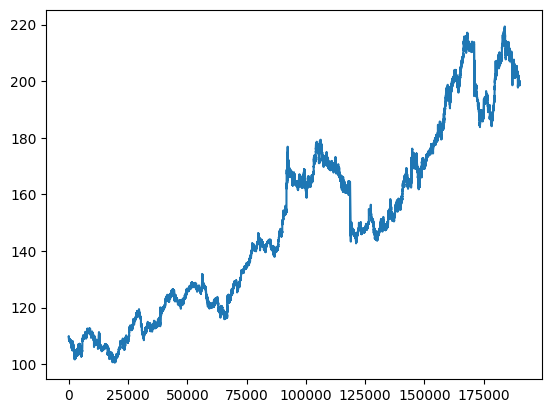

In [ ]:
plt.plot(close_prices-20)

(array([1.9000e+01, 1.5800e+02, 3.0000e+02, 3.8300e+02, 4.7800e+02,
        5.7700e+02, 6.5200e+02, 8.6100e+02, 1.0160e+03, 1.1860e+03,
        1.3730e+03, 1.6830e+03, 2.2520e+03, 3.2670e+03, 5.4900e+03,
        1.0969e+04, 2.3836e+04, 4.1620e+04, 4.5666e+04, 2.9074e+04,
        1.1902e+04, 3.8520e+03, 1.1040e+03, 4.1100e+02, 2.7900e+02,
        2.1300e+02, 1.9900e+02, 1.6100e+02, 1.3000e+02, 1.2200e+02,
        1.2800e+02, 1.2000e+02, 8.3000e+01, 7.0000e+01, 6.5000e+01,
        4.5000e+01, 5.1000e+01, 5.4000e+01, 4.9000e+01, 2.9000e+01,
        3.5000e+01, 2.6000e+01, 3.7000e+01, 3.0000e+01, 2.7000e+01,
        2.2000e+01, 2.5000e+01, 1.0000e+01, 1.6000e+01, 1.0000e+01]),
 array([0.09920772, 0.11225701, 0.12530631, 0.1383556 , 0.15140489,
        0.16445419, 0.17750347, 0.19055277, 0.20360206, 0.21665135,
        0.22970065, 0.24274993, 0.25579923, 0.26884851, 0.28189781,
        0.29494712, 0.30799639, 0.3210457 , 0.33409497, 0.34714428,
        0.36019358, 0.37324286, 0.38629216, 0.

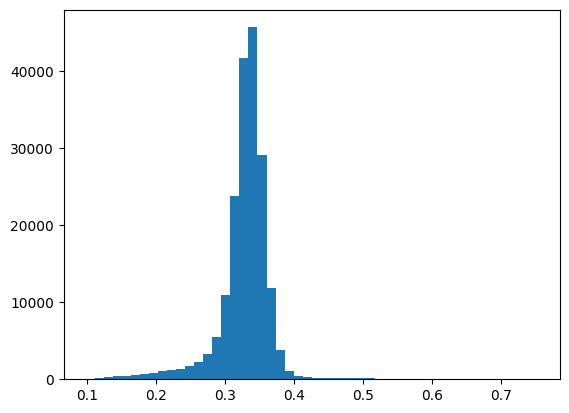

In [ ]:
plt.hist(preds[:, 0, 0], bins=50)